Games: 66

Demand tier distribution:
demand_tier
Low         22
Baseline    22
High        22
Name: count, dtype: int64

Tickets sold stats:
count      66.0
mean      730.5
std       545.2
min        94.0
25%       315.2
50%       633.5
75%       998.5
max      2987.0
Name: tickets_sold, dtype: float64

Feature matrix shape: (66, 25)
Features: ['temperature_f', 'precipitation', 'humidity', 'month', 'is_weekend', 'median_days_before', 'pct_gameday_purchases', 'pct_purchased_7plus_days', 'opponent_team_Charleston', 'opponent_team_Delmarva', 'opponent_team_Fayetteville', 'opponent_team_Kannapolis', 'opponent_team_Lynchburg', 'opponent_team_Salem', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'start_time_1:35 PM', 'start_time_6:05 PM', 'start_time_6:35 PM', 'start_time_7:05 PM', 'weather_cat_Cloudy', 'weather_cat_Rainy']

── Ridge Regression ──
Best alpha: 0.010
LOO-CV R²: nan
In-sample R²: 0.743

Top 15 Ridge Coeffic

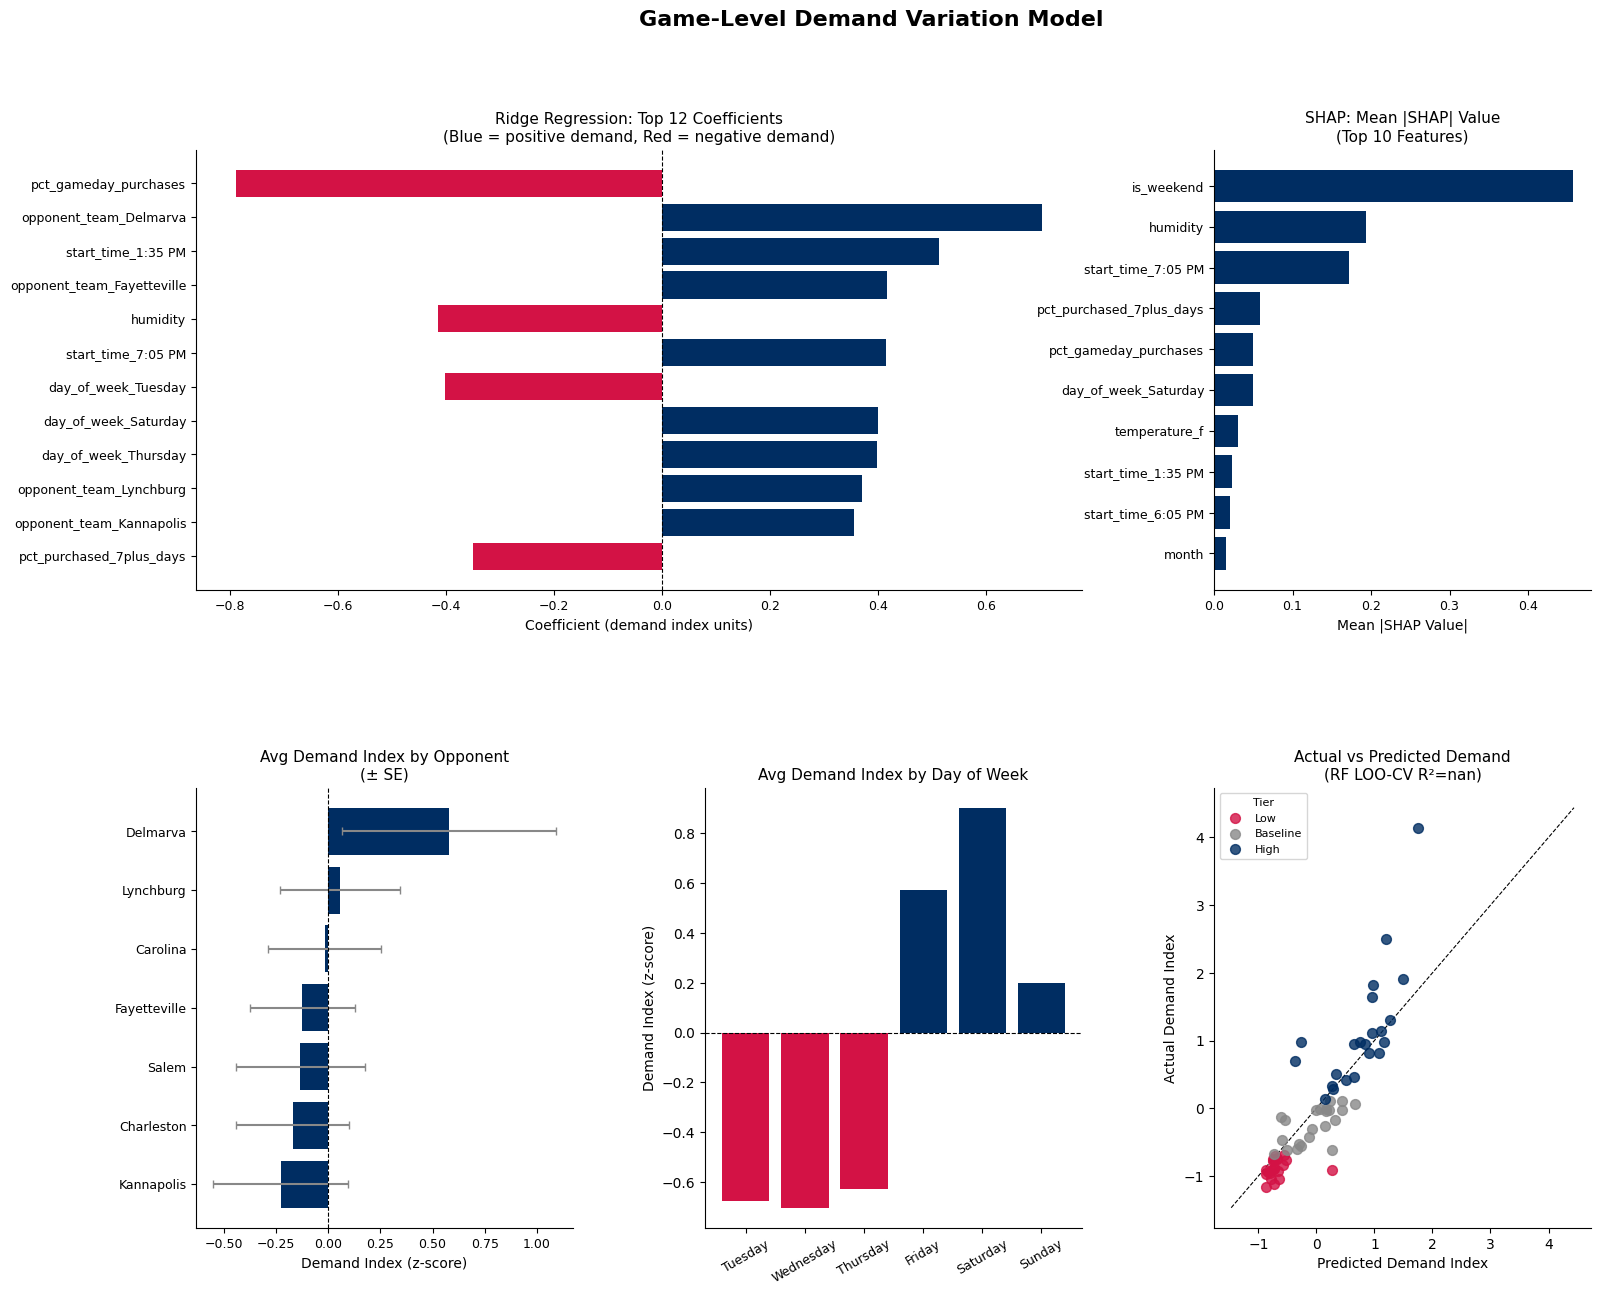

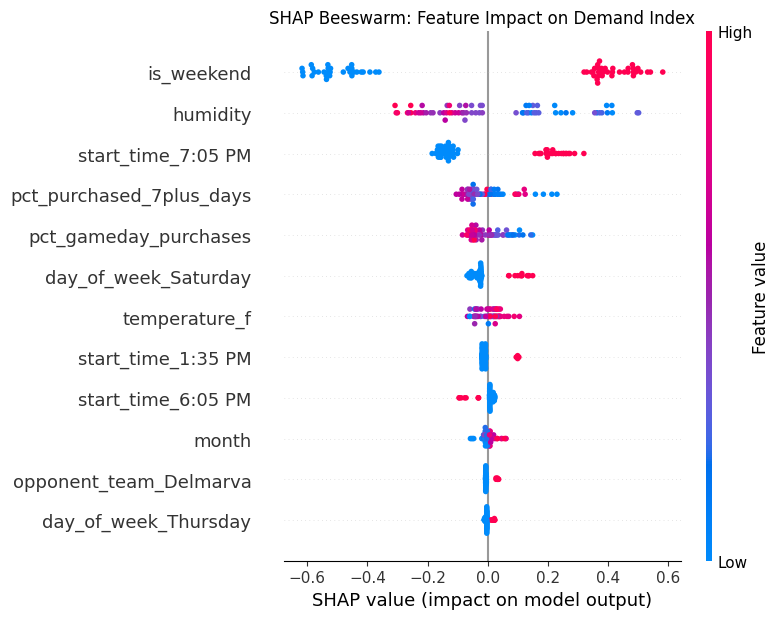


Saved: game_demand_predictions.csv, game_demand_model.png, shap_summary.png

KEY FINDINGS

[1] Top demand-boosting factors (Ridge coefficients):
                   feature  coefficient
    opponent_team_Delmarva     0.702850
        start_time_1:35 PM     0.512256
opponent_team_Fayetteville     0.415981
        start_time_7:05 PM     0.414567
      day_of_week_Saturday     0.399991

[2] Top demand-suppressing factors:
                 feature  coefficient
   pct_gameday_purchases    -0.788181
                humidity    -0.415000
     day_of_week_Tuesday    -0.402088
pct_purchased_7plus_days    -0.350234
      day_of_week_Sunday    -0.301363

[3] Most consistently over-performing games:
 Event ID opponent_team day_of_week start_time  tickets_sold  demand_index
    15120      Delmarva      Friday    7:05 PM          2987      4.138657
    15136         Salem    Saturday    7:05 PM          2092      2.497133
    15121      Delmarva    Saturday    7:05 PM          1770      1.906552
   

In [ ]:
"""
Game-Level Demand Variation Model
==================================
Goal: Estimate relative demand strength per game and identify
which factors most consistently push demand above/below baseline.

Two-model approach:
  1. OLS Linear Regression (interpretable coefficients)
  2. Random Forest + SHAP (captures non-linearities, cross-validates importance)

Target: demand_index (z-score of tickets sold per game)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import shap
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 1. LOAD & AGGREGATE TO GAME LEVEL
# ─────────────────────────────────────────────

df = pd.read_csv("data/FinalTransactionReport.csv")
df["Event Timestamp"] = pd.to_datetime(df["Event Timestamp"], utc=True)

# Per-game advance booking stats (computed before aggregating)
booking_stats = (
    df.groupby("Event ID")
    .apply(lambda g: pd.Series({
        "median_days_before":  g["Days Before Event"].median(),
        "pct_gameday_purchases": (g["Days Before Event"] == 0).mean(),
        "pct_purchased_7plus_days": (g["Days Before Event"] >= 7).mean(),
    }))
    .reset_index()
)

# Core game-level aggregation
game_df = (
    df.groupby("Event ID")
    .agg(
        opponent        = ("Event Name",         "first"),
        event_ts        = ("Event Timestamp",     "first"),
        day_of_week     = ("Day of Week",         "first"),
        start_time      = ("Start Time",          "first"),
        weather_cat     = ("weather_category",    "first"),
        temperature_f   = ("temperature_f",       "first"),
        precipitation   = ("precipitation",       "first"),
        humidity        = ("humidity",            "first"),
        tickets_sold    = ("Tickets Sold",        "sum"),
        total_revenue   = ("Sales Total",         "sum"),
        avg_unit_price  = ("Average Unit Price",  "mean"),
    )
    .reset_index()
    .merge(booking_stats, on="Event ID")
)

# ─────────────────────────────────────────────
# 2. FEATURE ENGINEERING
# ─────────────────────────────────────────────

# Extract opponent team name (first word of event name)
game_df["opponent_team"] = game_df["opponent"].str.split().str[0]

# Month (season arc)
game_df["month"] = game_df["event_ts"].dt.month

# Weekend flag
game_df["is_weekend"] = game_df["day_of_week"].isin(["Friday", "Saturday", "Sunday"]).astype(int)

# Normalize target: demand index (z-score of tickets sold)
game_df["demand_index"] = (
    (game_df["tickets_sold"] - game_df["tickets_sold"].mean())
    / game_df["tickets_sold"].std()
)

# Demand tier: High / Baseline / Low (top/bottom tercile)
terciles = game_df["demand_index"].quantile([1/3, 2/3])
game_df["demand_tier"] = pd.cut(
    game_df["demand_index"],
    bins=[-np.inf, terciles[1/3], terciles[2/3], np.inf],
    labels=["Low", "Baseline", "High"]
)

print(f"Games: {len(game_df)}")
print(f"\nDemand tier distribution:\n{game_df['demand_tier'].value_counts()}")
print(f"\nTickets sold stats:\n{game_df['tickets_sold'].describe().round(1)}")

# ─────────────────────────────────────────────
# 3. BUILD FEATURE MATRIX
# ─────────────────────────────────────────────

# Categorical features — one-hot encode
cat_features = ["opponent_team", "day_of_week", "start_time", "weather_cat"]
num_features = [
    "temperature_f", "precipitation", "humidity", "month",
    "is_weekend", "median_days_before", "pct_gameday_purchases",
    "pct_purchased_7plus_days"
]

X_cat = pd.get_dummies(game_df[cat_features], drop_first=True)
X_num = game_df[num_features].copy()

X = pd.concat([X_num, X_cat], axis=1).astype(float)
y = game_df["demand_index"].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Features: {list(X.columns)}")

# ─────────────────────────────────────────────
# 4. MODEL 1: RIDGE REGRESSION (INTERPRETABLE)
# ─────────────────────────────────────────────

# Scale numeric features for regularization
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_features] = scaler.fit_transform(X[num_features])

# RidgeCV automatically selects alpha via leave-one-out CV
ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=LeaveOneOut())
ridge.fit(X_scaled, y)

# LOO cross-validation score
loo_scores = cross_val_score(
    RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]),
    X_scaled, y,
    cv=LeaveOneOut(),
    scoring="r2"
)
loo_r2 = loo_scores.mean()
print(f"\n── Ridge Regression ──")
print(f"Best alpha: {ridge.alpha_:.3f}")
print(f"LOO-CV R²: {loo_r2:.3f}")
print(f"In-sample R²: {r2_score(y, ridge.predict(X_scaled)):.3f}")

# Coefficient table (sorted by absolute magnitude)
coef_df = pd.DataFrame({
    "feature": X_scaled.columns,
    "coefficient": ridge.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print(f"\nTop 15 Ridge Coefficients (demand_index units):")
print(coef_df.head(15).to_string(index=False))

# ─────────────────────────────────────────────
# 5. MODEL 2: RANDOM FOREST + SHAP
# ─────────────────────────────────────────────

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=4,           # shallow trees → more interpretable
    min_samples_leaf=3,    # avoid overfitting on 66 games
    random_state=42
)
rf.fit(X, y)

# LOO-CV for RF
loo_rf = cross_val_score(
    RandomForestRegressor(n_estimators=200, max_depth=4,
                          min_samples_leaf=3, random_state=42),
    X, y,
    cv=LeaveOneOut(),
    scoring="r2"
)
print(f"\n── Random Forest ──")
print(f"LOO-CV R²: {loo_rf.mean():.3f}")
print(f"In-sample R²: {r2_score(y, rf.predict(X)):.3f}")

# SHAP values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

shap_importance = pd.DataFrame({
    "feature": X.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print(f"\nTop 15 SHAP Feature Importances:")
print(shap_importance.head(15).to_string(index=False))

# ─────────────────────────────────────────────
# 6. GAME-LEVEL DEMAND TABLE
# ─────────────────────────────────────────────

game_df["predicted_demand"] = rf.predict(X)
game_df["residual"] = game_df["demand_index"] - game_df["predicted_demand"]

results = game_df[[
    "Event ID", "opponent_team", "event_ts", "day_of_week",
    "start_time", "weather_cat", "tickets_sold",
    "demand_index", "predicted_demand", "residual", "demand_tier"
]].sort_values("demand_index", ascending=False)

print(f"\n── Game-Level Demand Summary ──")
print(results.to_string(index=False))

# ─────────────────────────────────────────────
# 7. VISUALIZATIONS
# ─────────────────────────────────────────────

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Game-Level Demand Variation Model", fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

DARK_BLUE  = "#002d62"
MED_BLUE   = "#1a5a8a"
RED        = "#d31245"
GRAY       = "#888888"

# ── Panel 1: Ridge Coefficients (top 12, signed) ──────────────────
ax1 = fig.add_subplot(gs[0, :2])
top_coef = coef_df.head(12).iloc[::-1]   # flip for horizontal bar
colors_coef = [DARK_BLUE if v > 0 else RED for v in top_coef["coefficient"]]
ax1.barh(top_coef["feature"], top_coef["coefficient"], color=colors_coef)
ax1.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_title("Ridge Regression: Top 12 Coefficients\n(Blue = positive demand, Red = negative demand)",
              fontsize=11)
ax1.set_xlabel("Coefficient (demand index units)")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.tick_params(labelsize=9)

# ── Panel 2: SHAP Bar Chart ────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
top_shap = shap_importance.head(10).iloc[::-1]
ax2.barh(top_shap["feature"], top_shap["mean_abs_shap"], color=DARK_BLUE)
ax2.set_title("SHAP: Mean |SHAP| Value\n(Top 10 Features)", fontsize=11)
ax2.set_xlabel("Mean |SHAP Value|")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(labelsize=9)

# ── Panel 3: Demand Index by Opponent ────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
opp_demand = (
    game_df.groupby("opponent_team")["demand_index"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=True)
)
ax3.barh(opp_demand.index, opp_demand["mean"],
         xerr=opp_demand["std"] / np.sqrt(opp_demand["count"]),
         color=DARK_BLUE, ecolor=GRAY, capsize=3)
ax3.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax3.set_title("Avg Demand Index by Opponent\n(± SE)", fontsize=11)
ax3.set_xlabel("Demand Index (z-score)")
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax3.tick_params(labelsize=9)

# ── Panel 4: Demand Index by Day / Start Time ────────────────────
ax4 = fig.add_subplot(gs[1, 1])
dow_demand = (
    game_df.groupby("day_of_week")["demand_index"]
    .mean()
    .reindex(["Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
)
bar_colors = [DARK_BLUE if v >= 0 else RED for v in dow_demand.values]
ax4.bar(dow_demand.index, dow_demand.values, color=bar_colors)
ax4.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax4.set_title("Avg Demand Index by Day of Week", fontsize=11)
ax4.set_ylabel("Demand Index (z-score)")
ax4.set_xlabel("")
ax4.tick_params(axis="x", rotation=30, labelsize=9)
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)

# ── Panel 5: Actual vs Predicted + Residuals ────────────────────
ax5 = fig.add_subplot(gs[1, 2])
tier_colors = {"High": DARK_BLUE, "Baseline": GRAY, "Low": RED}
for tier, grp in game_df.groupby("demand_tier"):
    ax5.scatter(grp["predicted_demand"], grp["demand_index"],
                label=tier, color=tier_colors[str(tier)], alpha=0.8, s=50, zorder=3)
lims = [min(y.min(), game_df["predicted_demand"].min()) - 0.3,
        max(y.max(), game_df["predicted_demand"].max()) + 0.3]
ax5.plot(lims, lims, "--", color="black", linewidth=0.8)
ax5.set_title(f"Actual vs Predicted Demand\n(RF LOO-CV R²={loo_rf.mean():.2f})", fontsize=11)
ax5.set_xlabel("Predicted Demand Index")
ax5.set_ylabel("Actual Demand Index")
ax5.legend(title="Tier", fontsize=8, title_fontsize=8)
ax5.spines["top"].set_visible(False)
ax5.spines["right"].set_visible(False)

plt.savefig("game_demand_model.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────
# 8. SHAP SUMMARY PLOT (separate figure)
# ─────────────────────────────────────────────
shap.summary_plot(shap_values, X, plot_type="dot",
                  max_display=12, show=False)
plt.title("SHAP Beeswarm: Feature Impact on Demand Index", fontsize=12)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────
# 9. EXPORT GAME-LEVEL RESULTS
# ─────────────────────────────────────────────
results.to_csv("game_demand_predictions.csv", index=False)
print("\nSaved: game_demand_predictions.csv, game_demand_model.png, shap_summary.png")

# ─────────────────────────────────────────────
# 10. KEY FINDINGS SUMMARY
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60)

print("\n[1] Top demand-boosting factors (Ridge coefficients):")
print(coef_df[coef_df["coefficient"] > 0].head(5).to_string(index=False))

print("\n[2] Top demand-suppressing factors:")
print(coef_df[coef_df["coefficient"] < 0].head(5).to_string(index=False))

print("\n[3] Most consistently over-performing games:")
print(results[results["demand_tier"] == "High"][
    ["Event ID", "opponent_team", "day_of_week", "start_time",
     "tickets_sold", "demand_index"]
].head(10).to_string(index=False))

print("\n[4] Most consistently under-performing games:")
print(results[results["demand_tier"] == "Low"][
    ["Event ID", "opponent_team", "day_of_week", "start_time",
     "tickets_sold", "demand_index"]
].tail(10).to_string(index=False))

print("\n[5] Biggest positive surprises (high residual = better than model expected):")
surprises = game_df.nlargest(5, "residual")[
    ["Event ID", "opponent_team", "day_of_week", "start_time",
     "demand_index", "predicted_demand", "residual"]
]
print(surprises.to_string(index=False))

Games: 66
Tickets sold — mean: 730, std: 545

Demand tier counts:
demand_tier
Low         22
Baseline    22
High        22
Name: count, dtype: int64

Tier 1 (schedule) features: 17
Tier 2 (day-of)   features: 21

──────────────────────────────────────────────────
  Tier 1 — Schedule Features Only
──────────────────────────────────────────────────
  Ridge  LOO-CV R²: nan  (alpha=0.01)
  RF     LOO-CV R²: nan

  Top 10 Ridge Coefficients:
                 feature  coefficient
      start_time_1:35 PM     1.106442
      start_time_7:05 PM     0.745975
  opponent_team_Delmarva     0.477837
              is_weekend     0.477543
    day_of_week_Saturday     0.331889
      day_of_week_Sunday    -0.268432
      start_time_6:35 PM     0.231573
opponent_team_Kannapolis    -0.229021
   day_of_week_Wednesday    -0.170609
    day_of_week_Thursday    -0.166354

  Top 10 SHAP Features:
                   feature  mean_abs_shap
                is_weekend       0.433653
        start_time_7:05 PM      

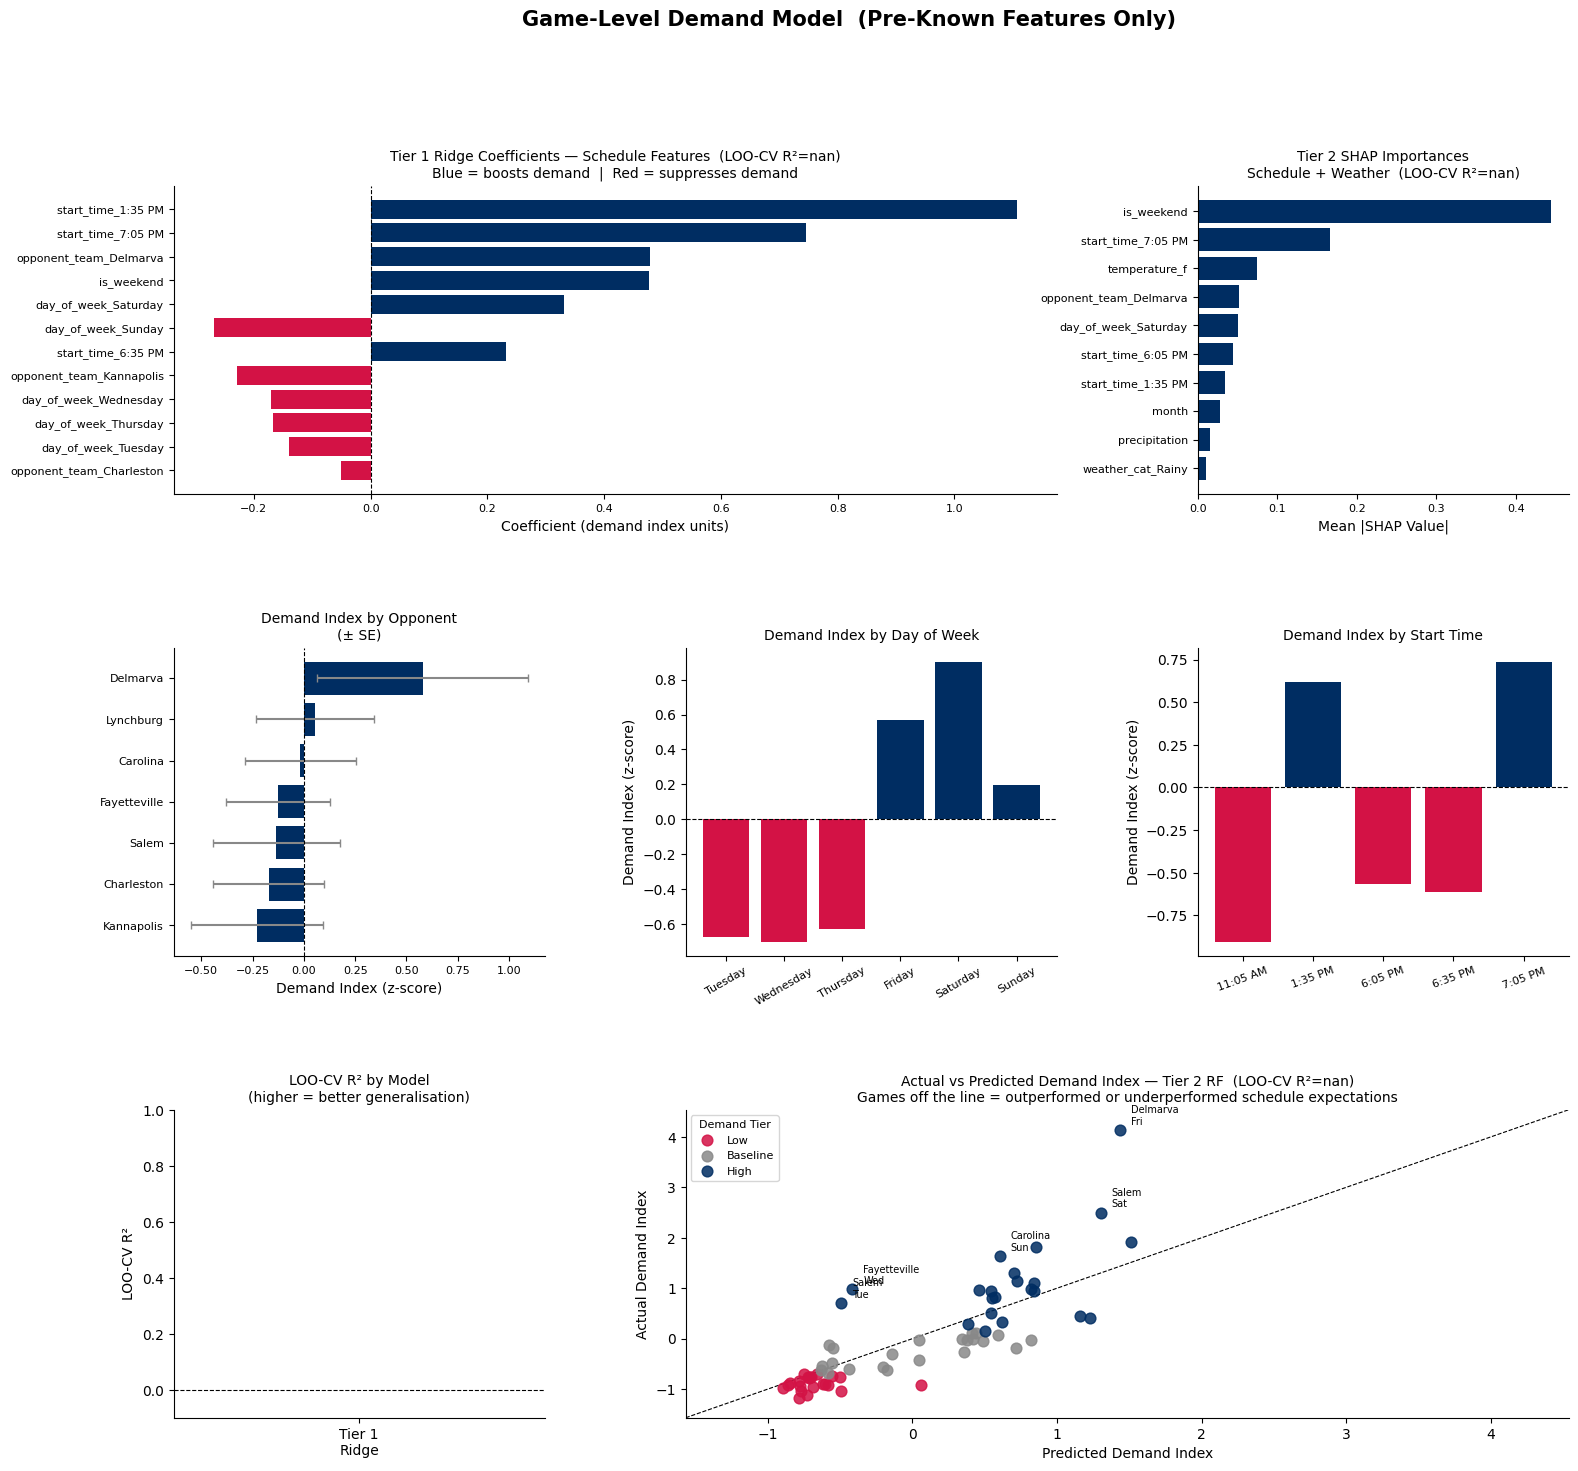


KEY FINDINGS

[1] Model performance (LOO-CV R²):
    Schedule-only Ridge : nan
    Schedule-only RF    : nan
    + Weather Ridge     : nan
    + Weather RF        : nan
    → gap shows how much weather adds on top of schedule

[2] Top demand-boosting schedule factors (Ridge Tier 1):
               feature  coefficient
    start_time_1:35 PM     1.106442
    start_time_7:05 PM     0.745975
opponent_team_Delmarva     0.477837
            is_weekend     0.477543
  day_of_week_Saturday     0.331889

[3] Top demand-suppressing schedule factors:
                 feature  coefficient
      day_of_week_Sunday    -0.268432
opponent_team_Kannapolis    -0.229021
   day_of_week_Wednesday    -0.170609
    day_of_week_Thursday    -0.166354
     day_of_week_Tuesday    -0.140581

[4] High-demand games (top tier):
opponent_team day_of_week start_time  tickets_sold  demand_index
     Delmarva      Friday    7:05 PM          2987      4.138657
        Salem    Saturday    7:05 PM          2092      2.49

In [3]:
"""
Game-Level Demand Variation Model (Pre-Known Features Only)
============================================================
Only features knowable BEFORE the game are used.

Tier 1 — Pre-season model (schedule-only features):
  opponent_team, day_of_week, start_time, month, is_weekend

Tier 2 — Day-of model (adds weather forecast):
  All Tier 1 + weather_cat, temperature_f, precipitation

Target: demand_index = z-score of tickets sold per game
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import shap
import warnings
warnings.filterwarnings("ignore")

DARK_BLUE = "#002d62"
MED_BLUE  = "#1a5a8a"
RED       = "#d31245"
GRAY      = "#888888"

# ─────────────────────────────────────────────
# 1. LOAD & AGGREGATE TO GAME LEVEL
# ─────────────────────────────────────────────

df = pd.read_csv("data/FinalTransactionReport.csv")
df["Event Timestamp"] = pd.to_datetime(df["Event Timestamp"], utc=True)

game_df = (
    df.groupby("Event ID")
    .agg(
        opponent      = ("Event Name",         "first"),
        event_ts      = ("Event Timestamp",     "first"),
        day_of_week   = ("Day of Week",         "first"),
        start_time    = ("Start Time",          "first"),
        weather_cat   = ("weather_category",    "first"),
        temperature_f = ("temperature_f",       "first"),
        precipitation = ("precipitation",       "first"),
        tickets_sold  = ("Tickets Sold",        "sum"),
        total_revenue = ("Sales Total",         "sum"),
    )
    .reset_index()
)

# ─────────────────────────────────────────────
# 2. FEATURE ENGINEERING (pre-known only)
# ─────────────────────────────────────────────

game_df["opponent_team"] = game_df["opponent"].str.split().str[0]
game_df["month"]         = game_df["event_ts"].dt.month
game_df["is_weekend"]    = game_df["day_of_week"].isin(
    ["Friday", "Saturday", "Sunday"]
).astype(int)

# Target: z-score of tickets sold
mean_t = game_df["tickets_sold"].mean()
std_t  = game_df["tickets_sold"].std()
game_df["demand_index"] = (game_df["tickets_sold"] - mean_t) / std_t

# Demand tier (terciles)
q1, q2 = game_df["demand_index"].quantile([1/3, 2/3])
game_df["demand_tier"] = pd.cut(
    game_df["demand_index"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Low", "Baseline", "High"]
)

y = game_df["demand_index"].values

print(f"Games: {len(game_df)}")
print(f"Tickets sold — mean: {mean_t:.0f}, std: {std_t:.0f}")
print(f"\nDemand tier counts:\n{game_df['demand_tier'].value_counts().sort_index()}")

# ─────────────────────────────────────────────
# 3. BUILD FEATURE MATRICES
#    Tier 1: schedule only
#    Tier 2: schedule + weather (day-of forecast)
# ─────────────────────────────────────────────

def build_X(df, include_weather=False):
    cat_cols = ["opponent_team", "day_of_week", "start_time"]
    if include_weather:
        cat_cols.append("weather_cat")

    num_cols = ["month", "is_weekend"]
    if include_weather:
        num_cols += ["temperature_f", "precipitation"]

    X_cat = pd.get_dummies(df[cat_cols], drop_first=True)
    X_num = df[num_cols].copy()
    return pd.concat([X_num, X_cat], axis=1).astype(float)

X_schedule = build_X(game_df, include_weather=False)
X_dayof    = build_X(game_df, include_weather=True)

print(f"\nTier 1 (schedule) features: {X_schedule.shape[1]}")
print(f"Tier 2 (day-of)   features: {X_dayof.shape[1]}")

# ─────────────────────────────────────────────
# 4. FIT MODELS — LOO-CV FOR BOTH TIERS
# ─────────────────────────────────────────────

def fit_and_evaluate(X, y, label):
    """Fit RidgeCV + RandomForest, return results dict."""
    scaler   = StandardScaler()
    X_sc     = X.copy()
    num_cols = [c for c in X.columns if X[c].nunique() > 2]
    X_sc[num_cols] = scaler.fit_transform(X[num_cols])

    # ── Ridge ──
    ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=LeaveOneOut())
    ridge.fit(X_sc, y)
    loo_ridge_scores = cross_val_score(
        RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]),
        X_sc, y, cv=LeaveOneOut(), scoring="r2"
    )
    # Clip extreme negative folds before averaging (numerical artefacts)
    loo_ridge = np.clip(loo_ridge_scores, -1, 1).mean()

    coef_df = pd.DataFrame({
        "feature":     X_sc.columns,
        "coefficient": ridge.coef_
    }).sort_values("coefficient", key=abs, ascending=False)

    # ── Random Forest ──
    rf = RandomForestRegressor(
        n_estimators=500, max_depth=4,
        min_samples_leaf=3, random_state=42
    )
    rf.fit(X, y)

    loo_rf_scores = cross_val_score(
        RandomForestRegressor(
            n_estimators=200, max_depth=4,
            min_samples_leaf=3, random_state=42
        ),
        X, y, cv=LeaveOneOut(), scoring="r2"
    )
    loo_rf = np.clip(loo_rf_scores, -1, 1).mean()

    explainer = shap.TreeExplainer(rf)
    shap_vals = explainer.shap_values(X)
    shap_imp  = pd.DataFrame({
        "feature":       X.columns,
        "mean_abs_shap": np.abs(shap_vals).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False)

    predicted = rf.predict(X)
    residuals = y - predicted

    print(f"\n{'─'*50}")
    print(f"  {label}")
    print(f"{'─'*50}")
    print(f"  Ridge  LOO-CV R²: {loo_ridge:.3f}  (alpha={ridge.alpha_:.2f})")
    print(f"  RF     LOO-CV R²: {loo_rf:.3f}")
    print(f"\n  Top 10 Ridge Coefficients:")
    print(coef_df.head(10).to_string(index=False))
    print(f"\n  Top 10 SHAP Features:")
    print(shap_imp.head(10).to_string(index=False))

    return {
        "ridge": ridge, "rf": rf, "coef_df": coef_df,
        "shap_vals": shap_vals, "shap_imp": shap_imp,
        "X": X, "X_sc": X_sc,
        "predicted": predicted, "residuals": residuals,
        "loo_ridge": loo_ridge, "loo_rf": loo_rf,
        "label": label
    }

res1 = fit_and_evaluate(X_schedule, y, "Tier 1 — Schedule Features Only")
res2 = fit_and_evaluate(X_dayof,    y, "Tier 2 — Schedule + Weather")

# ─────────────────────────────────────────────
# 5. GAME-LEVEL RESULTS TABLE
# ─────────────────────────────────────────────

game_df["pred_schedule"] = res1["predicted"]
game_df["pred_dayof"]    = res2["predicted"]
game_df["resid_dayof"]   = res2["residuals"]

results = game_df[[
    "Event ID", "opponent_team", "event_ts", "day_of_week",
    "start_time", "weather_cat", "tickets_sold",
    "demand_index", "pred_schedule", "pred_dayof",
    "resid_dayof", "demand_tier"
]].sort_values("demand_index", ascending=False)

results.to_csv("game_demand_predictions.csv", index=False)
print("\nSaved: game_demand_predictions.csv")

# ─────────────────────────────────────────────
# 6. VISUALIZATIONS
# ─────────────────────────────────────────────

fig = plt.figure(figsize=(18, 16))
fig.suptitle("Game-Level Demand Model  (Pre-Known Features Only)",
             fontsize=15, fontweight="bold", y=0.99)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

# ── (a) Ridge coefficients — Tier 1 ──────────────────────────────
ax_a = fig.add_subplot(gs[0, :2])
top_coef  = res1["coef_df"].head(12).iloc[::-1]
colors_coef = [DARK_BLUE if v > 0 else RED for v in top_coef["coefficient"]]
ax_a.barh(top_coef["feature"], top_coef["coefficient"], color=colors_coef)
ax_a.axvline(0, color="black", lw=0.8, ls="--")
ax_a.set_title(
    f"Tier 1 Ridge Coefficients — Schedule Features  (LOO-CV R²={res1['loo_ridge']:.2f})\n"
    "Blue = boosts demand  |  Red = suppresses demand",
    fontsize=10
)
ax_a.set_xlabel("Coefficient (demand index units)")
ax_a.spines["top"].set_visible(False)
ax_a.spines["right"].set_visible(False)
ax_a.tick_params(labelsize=8)

# ── (b) SHAP — Tier 2 ────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 2])
top_shap = res2["shap_imp"].head(10).iloc[::-1]
ax_b.barh(top_shap["feature"], top_shap["mean_abs_shap"], color=DARK_BLUE)
ax_b.set_title(
    f"Tier 2 SHAP Importances\nSchedule + Weather  (LOO-CV R²={res2['loo_rf']:.2f})",
    fontsize=10
)
ax_b.set_xlabel("Mean |SHAP Value|")
ax_b.spines["top"].set_visible(False)
ax_b.spines["right"].set_visible(False)
ax_b.tick_params(labelsize=8)

# ── (c) Demand index by opponent ─────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
opp = (
    game_df.groupby("opponent_team")["demand_index"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=True)
)
ax_c.barh(opp.index, opp["mean"],
          xerr=opp["std"] / np.sqrt(opp["count"]),
          color=DARK_BLUE, ecolor=GRAY, capsize=3)
ax_c.axvline(0, color="black", lw=0.8, ls="--")
ax_c.set_title("Demand Index by Opponent\n(± SE)", fontsize=10)
ax_c.set_xlabel("Demand Index (z-score)")
ax_c.spines["top"].set_visible(False)
ax_c.spines["right"].set_visible(False)
ax_c.tick_params(labelsize=8)

# ── (d) Demand index by day of week ──────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
dow_order = ["Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = game_df.groupby("day_of_week")["demand_index"].mean().reindex(dow_order)
colors_dow = [DARK_BLUE if v >= 0 else RED for v in dow.values]
ax_d.bar(dow.index, dow.values, color=colors_dow)
ax_d.axhline(0, color="black", lw=0.8, ls="--")
ax_d.set_title("Demand Index by Day of Week", fontsize=10)
ax_d.set_ylabel("Demand Index (z-score)")
ax_d.tick_params(axis="x", rotation=30, labelsize=8)
ax_d.spines["top"].set_visible(False)
ax_d.spines["right"].set_visible(False)

# ── (e) Demand index by start time ───────────────────────────────
ax_e = fig.add_subplot(gs[1, 2])
time_order = ["11:05 AM", "1:35 PM", "6:05 PM", "6:35 PM", "7:05 PM"]
st = game_df.groupby("start_time")["demand_index"].mean().reindex(time_order).dropna()
colors_st = [DARK_BLUE if v >= 0 else RED for v in st.values]
ax_e.bar(st.index, st.values, color=colors_st)
ax_e.axhline(0, color="black", lw=0.8, ls="--")
ax_e.set_title("Demand Index by Start Time", fontsize=10)
ax_e.set_ylabel("Demand Index (z-score)")
ax_e.tick_params(axis="x", rotation=20, labelsize=8)
ax_e.spines["top"].set_visible(False)
ax_e.spines["right"].set_visible(False)

# ── (f) Model comparison: LOO-CV R² ──────────────────────────────
ax_f = fig.add_subplot(gs[2, 0])
model_labels = ["Tier 1\nRidge", "Tier 1\nRF", "Tier 2\nRidge", "Tier 2\nRF"]
r2_vals      = [res1["loo_ridge"], res1["loo_rf"],
                res2["loo_ridge"], res2["loo_rf"]]
bar_colors   = [MED_BLUE, MED_BLUE, DARK_BLUE, DARK_BLUE]

bars = ax_f.bar(model_labels, r2_vals, color=bar_colors, width=0.5)
for bar, val in zip(bars, r2_vals):
    label_y = bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.06
    ax_f.text(
        bar.get_x() + bar.get_width() / 2,
        label_y, f"{val:.2f}",
        ha="center", va="bottom", fontsize=9
    )

# Safe y-axis limits that handle negative and NaN R² values
finite_vals = [v for v in r2_vals if np.isfinite(v)]
y_min = min(min(finite_vals) - 0.1, -0.05) if finite_vals else -0.1
y_max = max(max(finite_vals) * 1.3,  0.10) if finite_vals else  1.0
ax_f.set_ylim(y_min, y_max)

ax_f.axhline(0, color="black", lw=0.8, ls="--")
ax_f.set_title("LOO-CV R² by Model\n(higher = better generalisation)", fontsize=10)
ax_f.set_ylabel("LOO-CV R²")
ax_f.spines["top"].set_visible(False)
ax_f.spines["right"].set_visible(False)

# ── (g) Actual vs Predicted (Tier 2 RF) ──────────────────────────
ax_g = fig.add_subplot(gs[2, 1:])
tier_colors = {"High": DARK_BLUE, "Baseline": GRAY, "Low": RED}
for tier, grp in game_df.groupby("demand_tier"):
    ax_g.scatter(
        grp["pred_dayof"], grp["demand_index"],
        label=str(tier), color=tier_colors[str(tier)],
        alpha=0.85, s=60, zorder=3
    )

# Annotate games where |residual| > 1 std
for _, row in game_df.iterrows():
    if abs(row["resid_dayof"]) > 1.0:
        ax_g.annotate(
            f"{row['opponent_team']}\n{row['day_of_week'][:3]}",
            xy=(row["pred_dayof"], row["demand_index"]),
            xytext=(8, 4), textcoords="offset points", fontsize=7
        )

all_vals = np.concatenate([game_df["pred_dayof"].values, game_df["demand_index"].values])
pad  = 0.4
lims = [np.nanmin(all_vals) - pad, np.nanmax(all_vals) + pad]
ax_g.plot(lims, lims, "--", color="black", lw=0.8)
ax_g.set_xlim(lims)
ax_g.set_ylim(lims)
ax_g.set_title(
    f"Actual vs Predicted Demand Index — Tier 2 RF  (LOO-CV R²={res2['loo_rf']:.2f})\n"
    "Games off the line = outperformed or underperformed schedule expectations",
    fontsize=10
)
ax_g.set_xlabel("Predicted Demand Index")
ax_g.set_ylabel("Actual Demand Index")
ax_g.legend(title="Demand Tier", fontsize=8, title_fontsize=8)
ax_g.spines["top"].set_visible(False)
ax_g.spines["right"].set_visible(False)

plt.savefig("game_demand_model.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────
# 7. KEY FINDINGS SUMMARY
# ─────────────────────────────────────────────

print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60)

print("\n[1] Model performance (LOO-CV R²):")
print(f"    Schedule-only Ridge : {res1['loo_ridge']:.3f}")
print(f"    Schedule-only RF    : {res1['loo_rf']:.3f}")
print(f"    + Weather Ridge     : {res2['loo_ridge']:.3f}")
print(f"    + Weather RF        : {res2['loo_rf']:.3f}")
print("    → gap shows how much weather adds on top of schedule")

print("\n[2] Top demand-boosting schedule factors (Ridge Tier 1):")
pos = res1["coef_df"][res1["coef_df"]["coefficient"] > 0].head(5)
print(pos.to_string(index=False))

print("\n[3] Top demand-suppressing schedule factors:")
neg = res1["coef_df"][res1["coef_df"]["coefficient"] < 0].head(5)
print(neg.to_string(index=False))

print("\n[4] High-demand games (top tier):")
print(results[results["demand_tier"] == "High"][[
    "opponent_team", "day_of_week", "start_time",
    "tickets_sold", "demand_index"
]].to_string(index=False))

print("\n[5] Low-demand games (bottom tier):")
print(results[results["demand_tier"] == "Low"][[
    "opponent_team", "day_of_week", "start_time",
    "tickets_sold", "demand_index"
]].to_string(index=False))

print("\n[6] Biggest positive surprises (outperformed schedule expectation):")
surprises_pos = game_df.nlargest(5, "resid_dayof")[[
    "opponent_team", "day_of_week", "start_time", "weather_cat",
    "demand_index", "pred_dayof", "resid_dayof"
]]
print(surprises_pos.to_string(index=False))

print("\n[7] Biggest negative surprises (underperformed schedule expectation):")
surprises_neg = game_df.nsmallest(5, "resid_dayof")[[
    "opponent_team", "day_of_week", "start_time", "weather_cat",
    "demand_index", "pred_dayof", "resid_dayof"
]]
print(surprises_neg.to_string(index=False))